# Analisis del Dataset, comprobacion y agrupacion de variables

Estructura del notebook:

1. Dimensiones y valores nulos
2. Calidad e integridad temporal
3. Numero de observaciones por mes/año
4. Comprobar variables temporales
5. Estadistica descriptiva
6. Distribución del precio (Histograma)
7. Matriz de correlacion
8. Matriz de Correlacion-Precio
9. Correlacion absoluta especto al precio
10. Correlación entre variables (Colinealidad)
11. Agrupacion de variables altamente relacionadas
12. Agrupación de variables de generación


Filas: 43,848
Columnas: 31

<class 'pandas.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   datetime                         43848 non-null  str    
 1   demand                           43848 non-null  float64
 2   year                             43848 non-null  int64  
 3   month                            43848 non-null  int64  
 4   day                              43848 non-null  int64  
 5   dayofweek                        43848 non-null  int64  
 6   is_weekend                       43848 non-null  int64  
 7   biogas                           43848 non-null  float64
 8   biomasa                          43848 non-null  float64
 9   ciclo_combinado                  43848 non-null  float64
 10  derivados_del_petroleo_o_carbon  43848 non-null  float64
 11  energia_residual                 43848 non-null  float64
 12  e

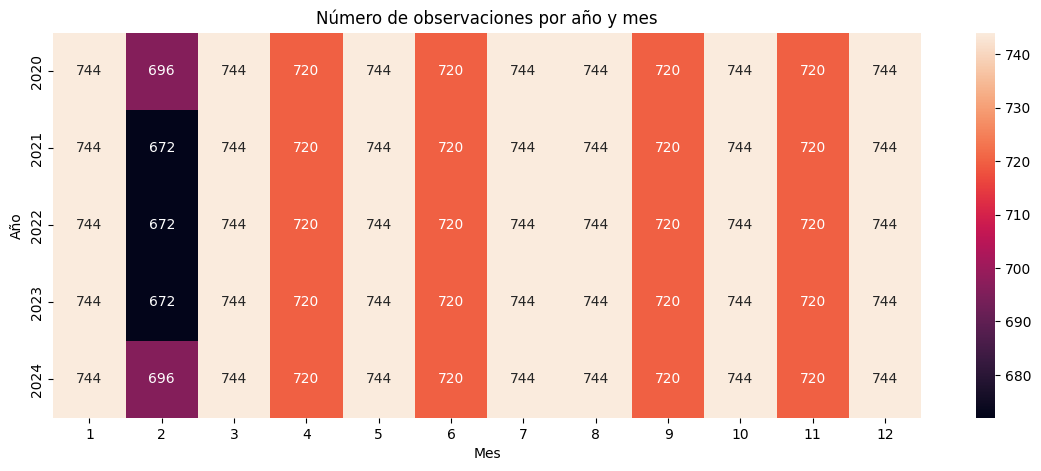

Errores en is_weekend: 0

                           ESTADÍSTICAS DESCRIPTIVAS                            
                                   count                 mean                  min                  25%                  50%                  75%                  max          std
datetime                           43848  2022-07-02 11:30:00  2020-01-01 00:00:00  2021-04-01 17:45:00  2022-07-02 11:30:00  2023-10-02 05:15:00  2024-12-31 23:00:00          NaN
demand                           43848.0         26895.187286             16116.83           23390.1275             26882.42           30139.8925             41828.83  4341.500369
year                             43848.0               2022.0               2020.0               2021.0               2022.0               2023.0               2024.0     1.415004
month                            43848.0             6.521073                  1.0                  4.0                  7.0                 10.0                 12.0     3.

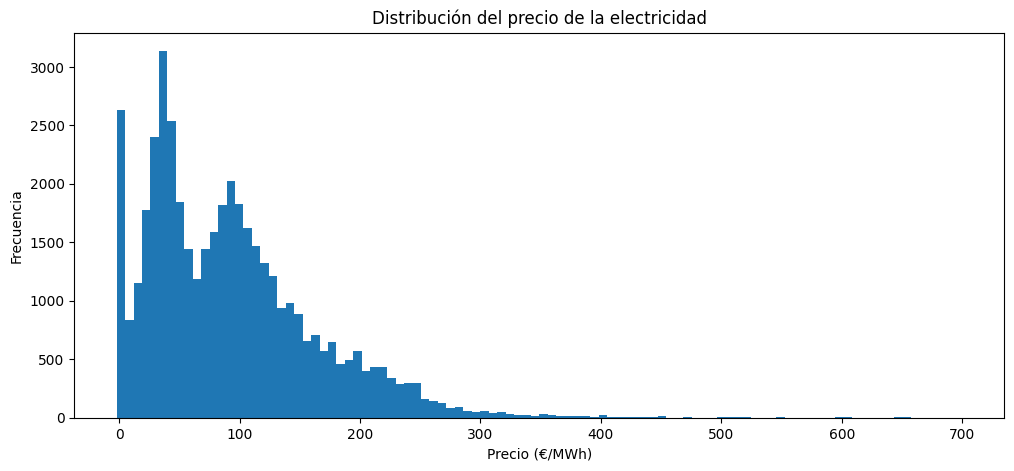

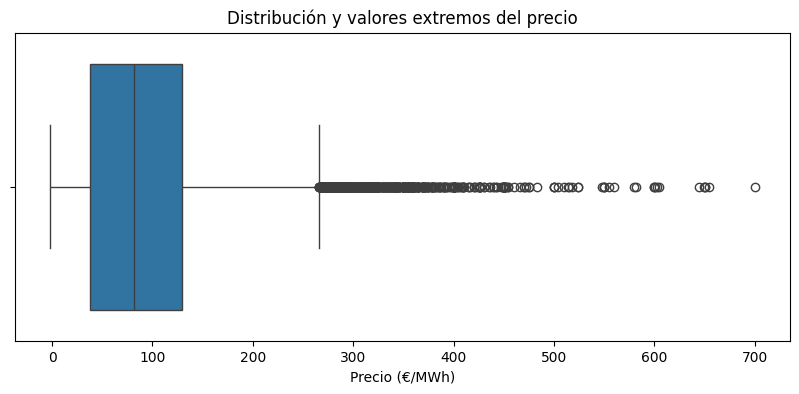


Matriz de correlación entre variables numéricas:

                                   demand          year         month  \
demand                           1.000000 -9.575521e-02 -6.765936e-02   
year                            -0.095755  1.000000e+00  8.828232e-14   
month                           -0.067659  8.828232e-14  1.000000e+00   
day                              0.011148 -4.189184e-14  9.702506e-03   
dayofweek                       -0.304654 -1.160460e-03  9.521224e-04   
is_weekend                      -0.388375  8.562625e-04 -1.405075e-03   
biogas                           0.091690 -6.467754e-01 -2.343551e-01   
biomasa                          0.115964 -4.719289e-01  5.733163e-02   
ciclo_combinado                  0.332387 -3.634877e-02  1.866947e-01   
derivados_del_petroleo_o_carbon  0.229112 -7.652951e-01 -2.627270e-03   
energia_residual                 0.354907 -1.417611e-01  6.795632e-02   
eolica_terrestre                 0.044179  3.823622e-02 -1.484703e-02   


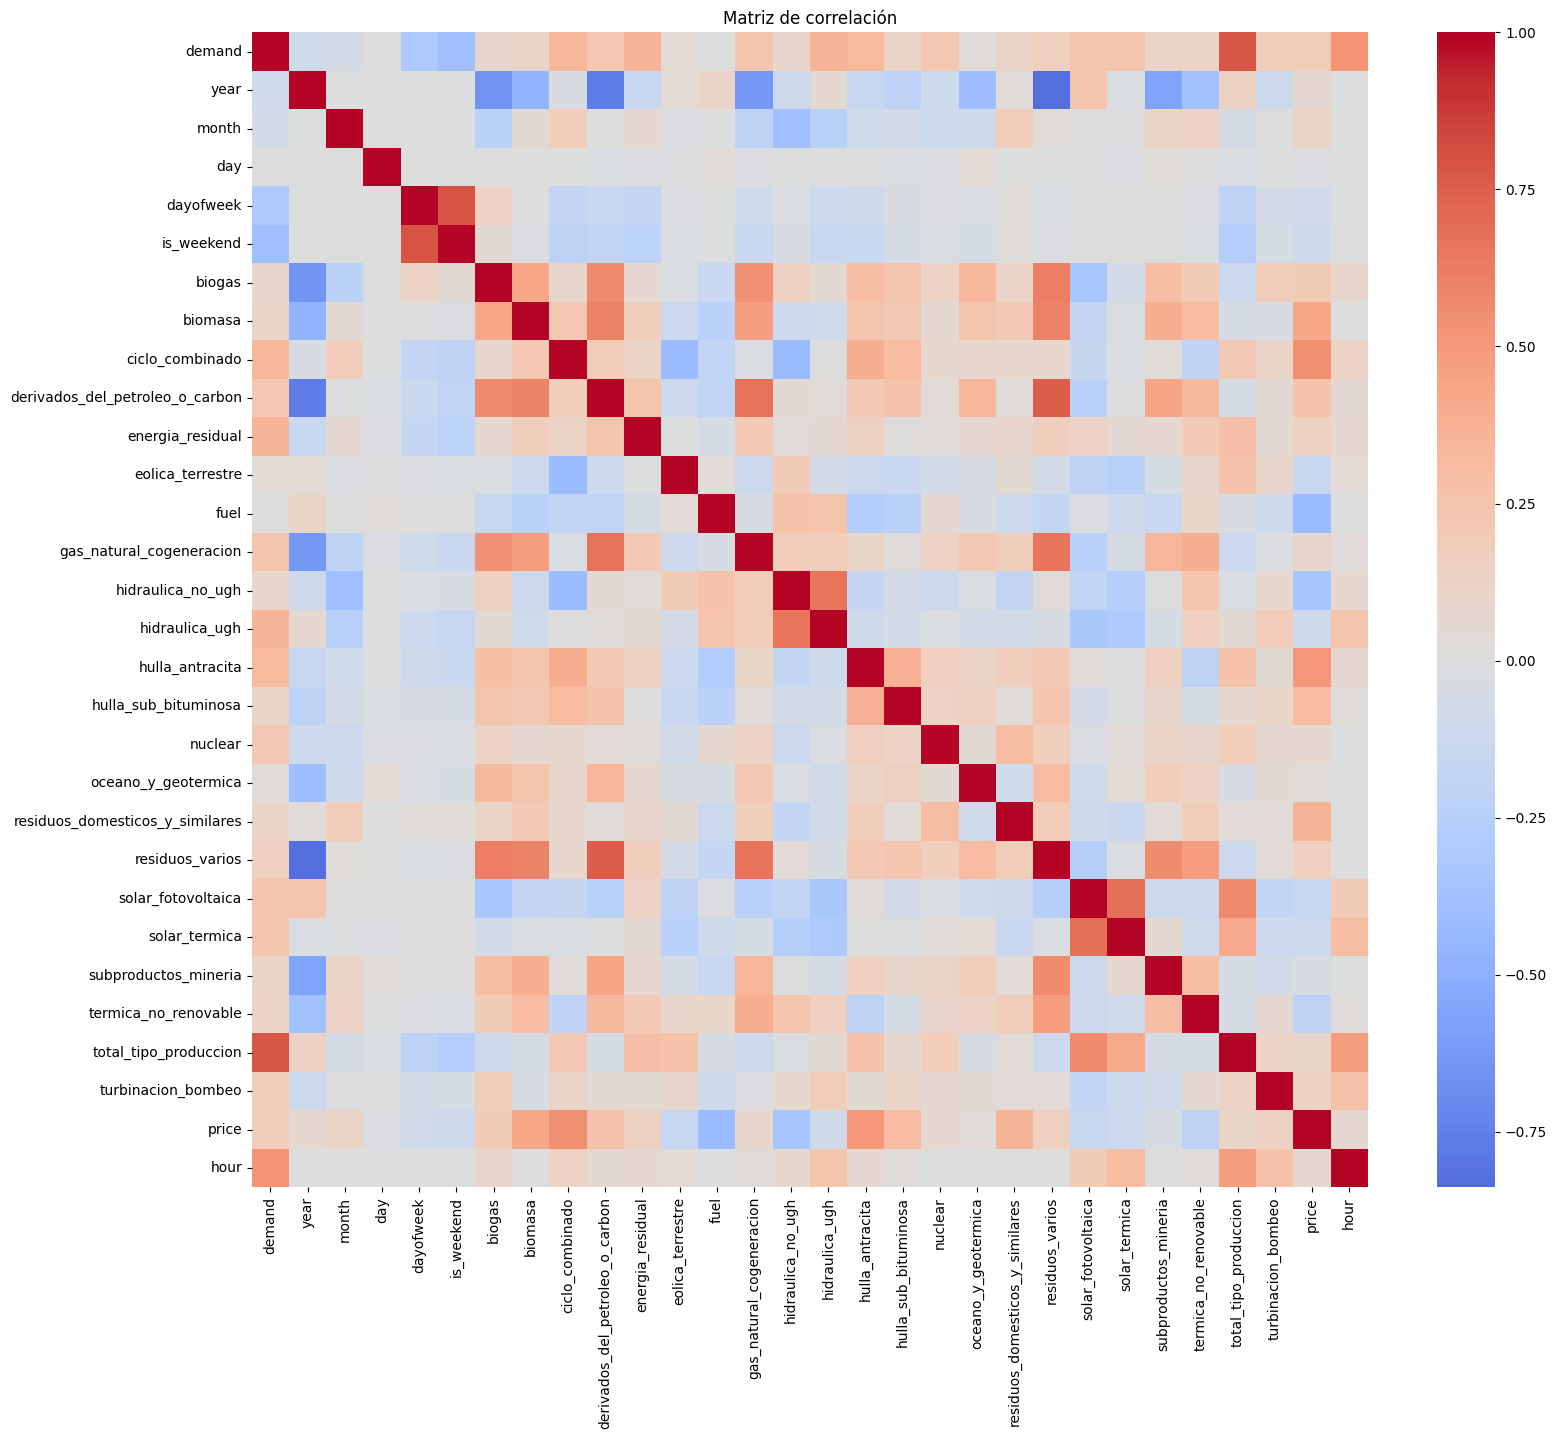


Correlación de cada variable con el precio:



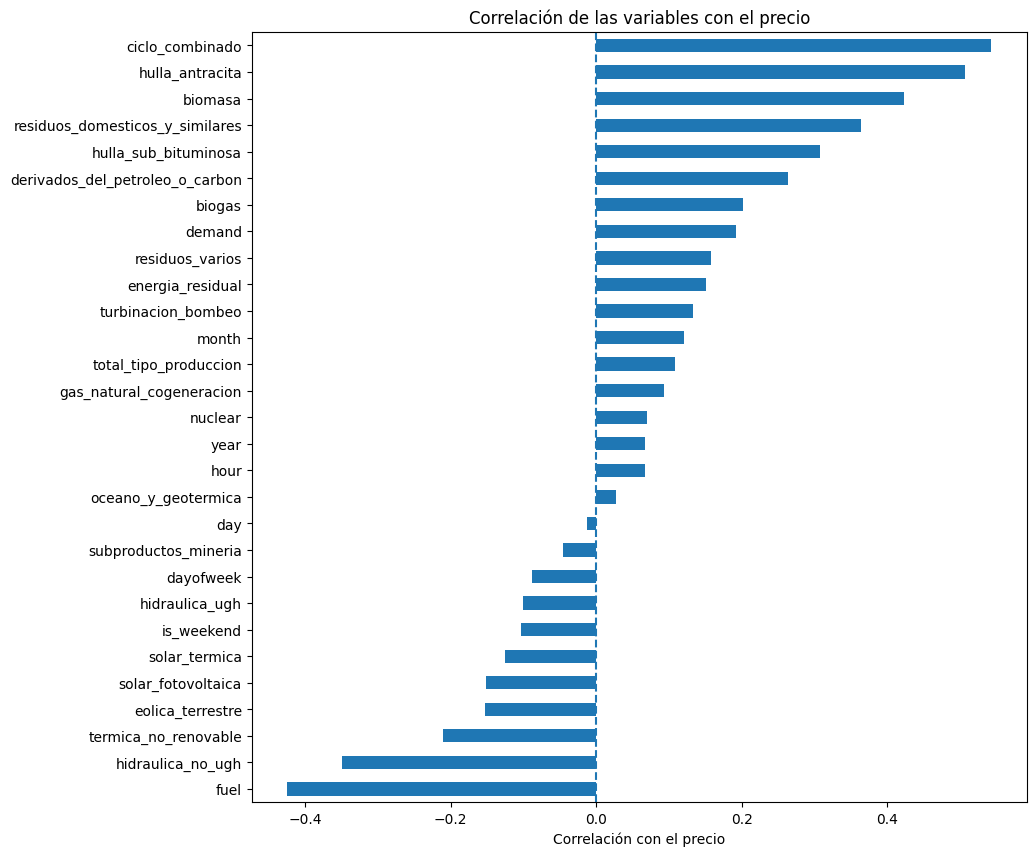


Correlación absoluta de cada variable con el precio:

Variables con mayor correlación absoluta con el precio:
 ciclo_combinado                    0.542858
hulla_antracita                    0.506014
fuel                               0.424915
biomasa                            0.422579
residuos_domesticos_y_similares    0.363387
hidraulica_no_ugh                  0.349422
hulla_sub_bituminosa               0.307477
derivados_del_petroleo_o_carbon    0.262672
termica_no_renovable               0.210346
biogas                             0.201830
Name: price, dtype: float64 



'\n# =========================\n# 10 Correlacio entre variables\n# =========================\n\n#Es posible que algunas esten fuertemente relacionadas entre si, por\n# lo que conviene eliminar algunas para evitar multicolinealidad en modelos de ML\n# basicamente permite detectar grupos de variables redundantes.\n\nprint("\nCorrelación entre variables:\n")\n\ncorr_variables = df_numeric.drop(columns=["price"]).corr()\n\n\n\n\n# =========================\n# 11 Correlaciones altas entre pares de variables\n# =========================\ncorr = df_numeric.drop(columns=["price"]).corr()\n\npares_altos = []\n\nfor i in range(len(corr.columns)):\n    for j in range(i + 1, len(corr.columns)):\n        valor = corr.iloc[i, j]\n        if abs(valor) >= 0.70:\n            pares_altos.append({\n                "variable_1": corr.columns[i],\n                "variable_2": corr.columns[j],\n                "correlacion": valor\n            })\n\npares_altos = pd.DataFrame(pares_altos)\n\nif not pares_

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

df = pd.read_csv(
    "Dataset_Unificado_2020_2024.csv",
    sep=";"
)

df.head()

# =========================
# 1 comprobamos dimensiones:
# =========================

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}\n")

#tipos de los datos:
df.info()

#Si hay valores nulos:
nulos = df.isnull().sum()

nulos = nulos[nulos > 0].sort_values(ascending=False)

print("\n Numero de valores nulos:", nulos.sum(), "\n")

print("\n")

# =========================
# 2 Comprobar el periodo temporal
# =========================

df["datetime"] = pd.to_datetime(df["datetime"])

#fechas de inicio y fin del dataset
print("fechas de inicio y fin del dataset")
print("Fecha mínima:", df["datetime"].min())
print("Fecha máxima:", df["datetime"].max(), "\n")

# Comprobar duplicados
duplicados_datetime = df["datetime"].duplicated().sum()
print("Timestamps(fechas) duplicados:", duplicados_datetime, "\n")


#Calculamos la diferencia entre observaciones:
diferencias = df["datetime"].diff()

diferencias.value_counts().sort_index()
#Normalmente deberías encontrar:  0 days 01:00:00
print(diferencias, "\n")

# =========================
# 3 Comprobar número de observaciones por año y mes
# =========================

print("Número de observaciones por año:")
df.groupby("year").size()

df.groupby("year")["datetime"].agg(["min", "max", "count"])

observaciones_mes = (
    df.groupby(["year", "month"])
      .size()
      .unstack(fill_value=0)
)

observaciones_mes

plt.figure(figsize=(14, 5))

sns.heatmap(
    observaciones_mes,
    annot=True,
    fmt="d"
)

plt.title("Número de observaciones por año y mes")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()

# =========================
# 4 Comprobar las variables temporales
# =========================

#Podemos comprobar que son coherentes con datetime:
comprobacion = pd.DataFrame({
    "year_correcto": df["year"] == df["datetime"].dt.year,
    "month_correcto": df["month"] == df["datetime"].dt.month,
    "day_correcto": df["day"] == df["datetime"].dt.day,
    "dayofweek_correcto": df["dayofweek"] == df["datetime"].dt.dayofweek,
    "hour_correcto": df["hour"] == df["datetime"].dt.hour
})

comprobacion.sum()

is_weekend_correcto = (
    df["is_weekend"] ==
    df["datetime"].dt.dayofweek.isin([5, 6]).astype(int)
)

print("Errores en is_weekend:", (~is_weekend_correcto).sum())

# =========================
# 5 Estadistica descriptiva
# =========================
#Esto permitira detectar valores sospechosos

#Primero identificamos las variables numéricas:
df.describe().T

#
estadisticas = df.describe().T

#
estadisticas[
    ["mean", "std", "min", "50%", "max"]
].sort_values("std", ascending=False)


print("\n" + "=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS".center(80))
print("=" * 80)
print(estadisticas.to_string())
print("=" * 80 + "\n")

# Mostrar resumen metricas mas importantes
print("=" * 80)
print("RESUMEN DE ESTADÍSTICAS (ordenado por desviación estándar)".center(80))
print("=" * 80)

resumen = estadisticas[["mean", "std", "min", "50%", "max"]].sort_values("std", ascending=False)
print(resumen.to_string())
print("=" * 80 + "\n")

# Opcional, mostrar que variables tienen mayor variabilidad
print("TOP 5 VARIABLES CON MAYOR DESVIACIÓN ESTÁNDAR:")
print(resumen.head(5)[["std"]].to_string())
print("\n")

print("TOP 5 VARIABLES CON MENOR DESVIACIÓN ESTÁNDAR:")
print(resumen.tail(5)[["std"]].to_string())

# =========================
# 6 Analizar el precio
# =========================

df["price"].describe()

#Histograma
plt.figure(figsize=(12, 5))

plt.hist(df["price"], bins=100)

plt.xlabel("Precio (€/MWh)")
plt.ylabel("Frecuencia")
plt.title("Distribución del precio de la electricidad")

plt.show()

# Diagrama de caja (boxplot) para detectar valores extremos
#Esto es particularmente interesante en electricidad porque el precio
#puede presentar valores extremos y episodios anomalos, incluidos precios
#negativos en determinados mercados/periodos

plt.figure(figsize=(10, 4))

sns.boxplot(x=df["price"])

plt.title("Distribución y valores extremos del precio")
plt.xlabel("Precio (€/MWh)")

plt.show()

# =========================
# 7 Matriz de correlación
# =========================
print("\nMatriz de correlación entre variables numéricas:\n")
df_numeric = df.select_dtypes(include=np.number)

correlacion = df_numeric.corr()

print(correlacion, "\n")
plt.figure(figsize=(18, 15))

sns.heatmap(
    correlacion,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")

plt.show()


# =========================
# 8 Correlación de cada variable con el precio
# =========================
print("\nCorrelación de cada variable con el precio:\n")

corr_price = (
    df_numeric.corr()["price"]
    .drop("price")
    .sort_values()
)

plt.figure(figsize=(10, 10))

corr_price.plot(kind="barh")

plt.xlabel("Correlación con el precio")
plt.title("Correlación de las variables con el precio")

plt.axvline(0, linestyle="--")

plt.show()


# =========================
# 9 Correlación absoluta
# =========================

#Para encontrar las variables que mas relacion tienen con el precio
print("\nCorrelación absoluta de cada variable con el precio:\n")

corr_price_abs = (
    df_numeric.corr()["price"]
    .drop("price")
    .abs()
    .sort_values(ascending=False)
)

print("Variables con mayor correlación absoluta con el precio:\n", corr_price_abs.head(10), "\n")

'''
# =========================
# 10 Correlacio entre variables
# =========================

#Es posible que algunas esten fuertemente relacionadas entre si, por
# lo que conviene eliminar algunas para evitar multicolinealidad en modelos de ML
# basicamente permite detectar grupos de variables redundantes.

print("\nCorrelación entre variables:\n")

corr_variables = df_numeric.drop(columns=["price"]).corr()




# =========================
# 11 Correlaciones altas entre pares de variables
# =========================
corr = df_numeric.drop(columns=["price"]).corr()

pares_altos = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        valor = corr.iloc[i, j]
        if abs(valor) >= 0.70:
            pares_altos.append({
                "variable_1": corr.columns[i],
                "variable_2": corr.columns[j],
                "correlacion": valor
            })

pares_altos = pd.DataFrame(pares_altos)

if not pares_altos.empty:
    # IMPORTANTE: Asignar el resultado de sort_values a una variable
    pares_altos = pares_altos.sort_values("correlacion", key=abs, ascending=False)
    print("Pares de variables con correlación ≥ 0.70:\n")
    print(pares_altos.to_string(index=False))  # to_string() muestra mejor el formato
    print("\n")
else:
    print("No se encontraron correlaciones ≥ 0.70")

'''




### Agrupacion de variables de Generacion Por Tipo de Tecnologia

1. 

2. Crear una tabla de evaluación de tecnologías

Esta sería una de las partes más útiles para tu memoria.

Calcula para cada tecnología:

media

desviación estándar

coeficiente de variación

mínimo/máximo

porcentaje de ceros

Pearson con price

Spearman con price

¿Por qué Pearson Y Spearman?

Porque no quieres asumir que la relación con el precio es exclusivamente lineal.

Pearson → relación lineal.

Spearman → relación monotónica.

Si una variable tiene baja Pearson pero alta Spearman, hay información que la correlación lineal no está capturando.


3. Detectar variables redundantes

Es decir, porca correlacion con el precio o muchos valores nulos (0s)

Pero cuidado:

Baja correlacion no significa variable inutil.

Una variable puede aportar información no lineal o interactuar con otras.

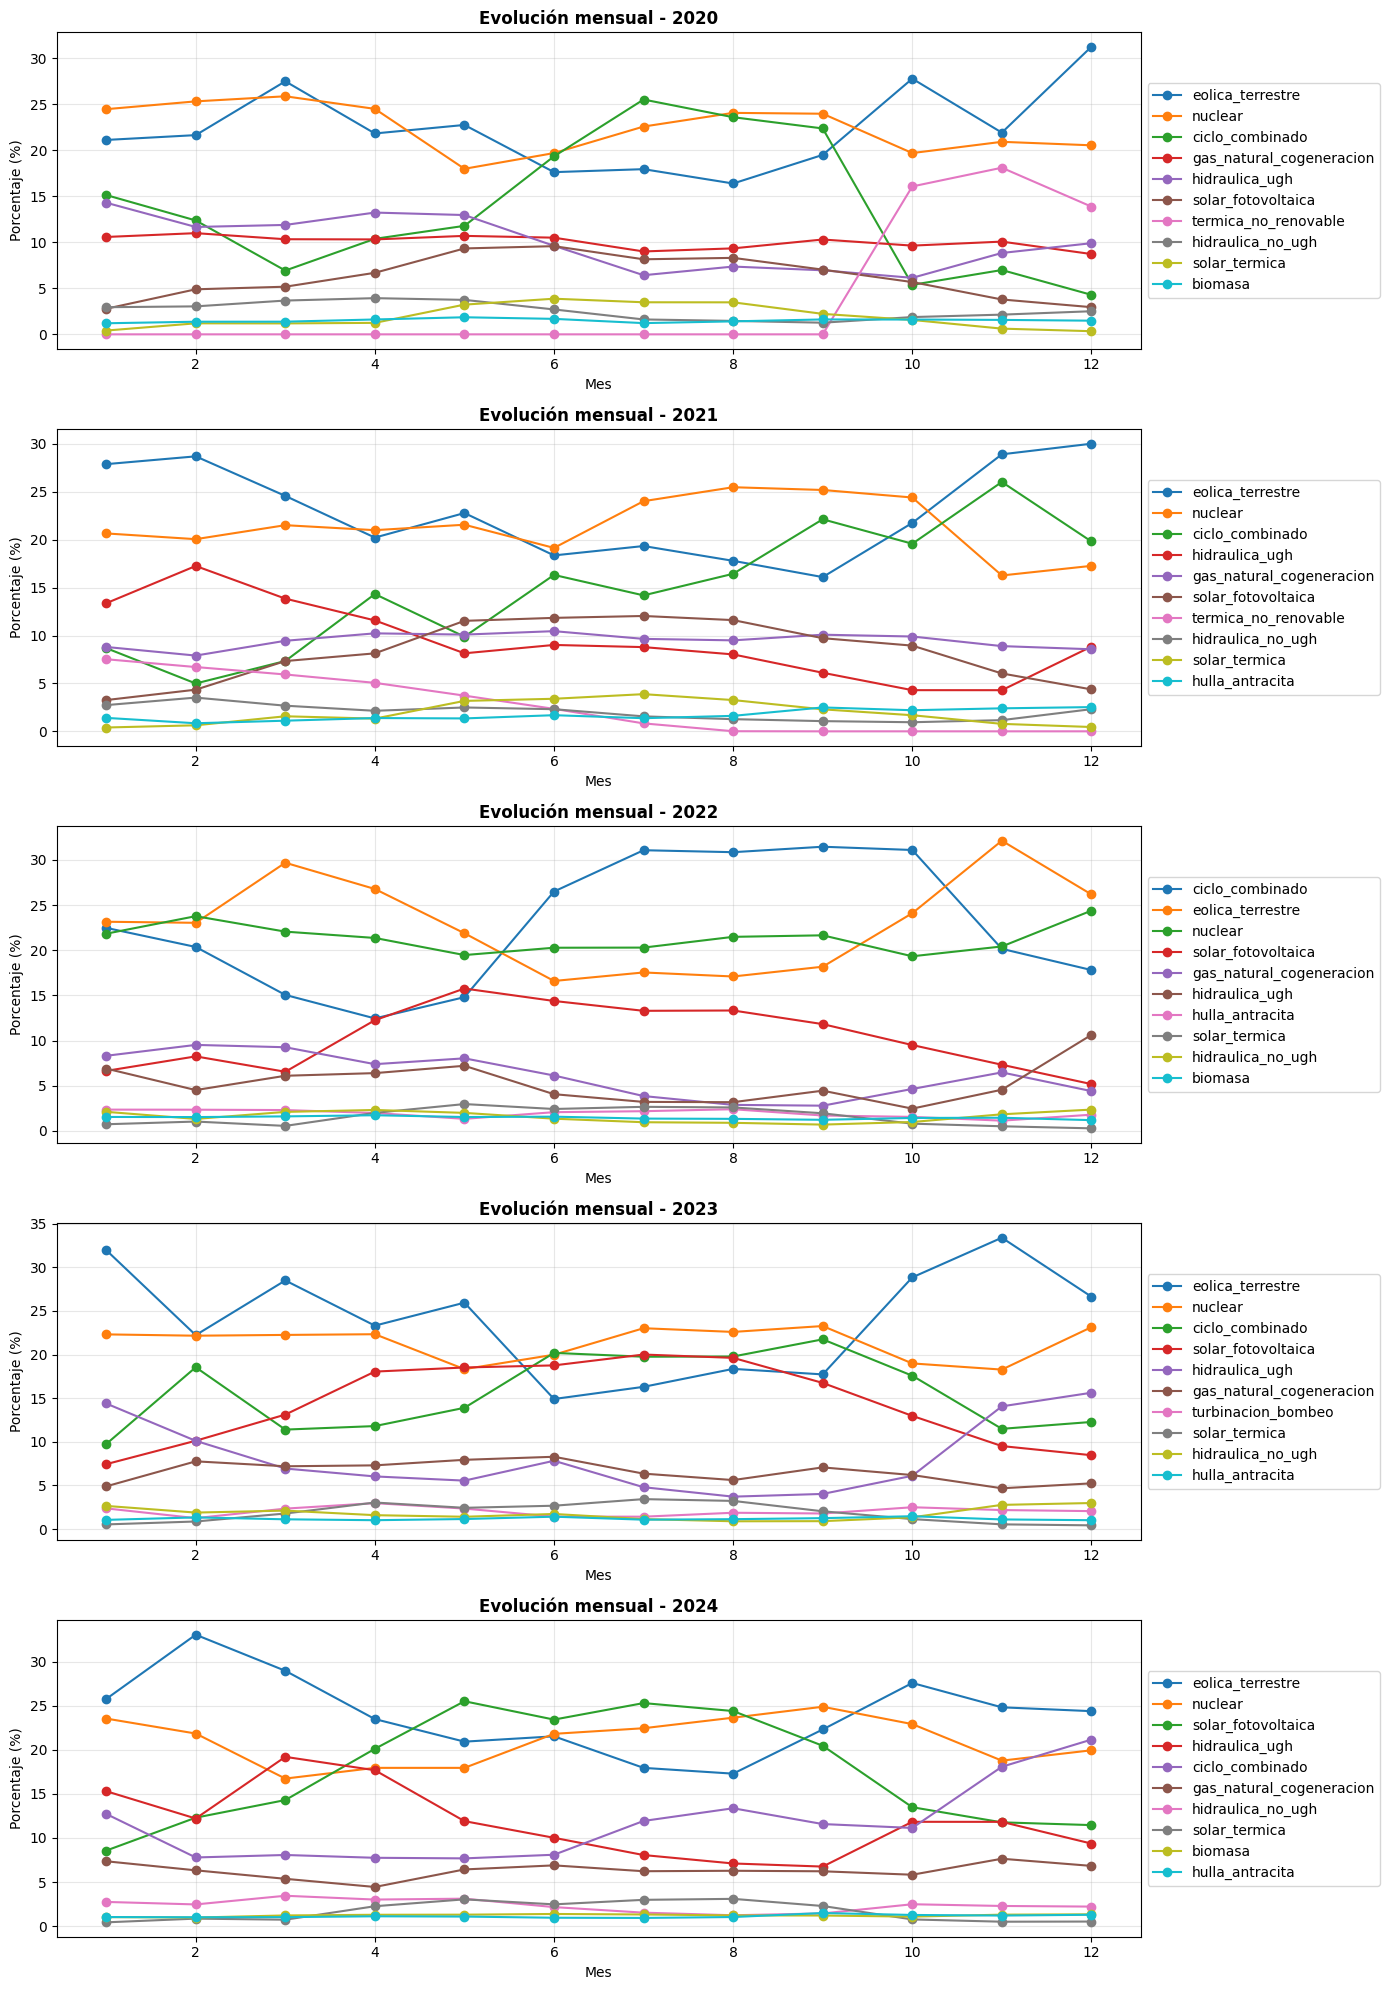

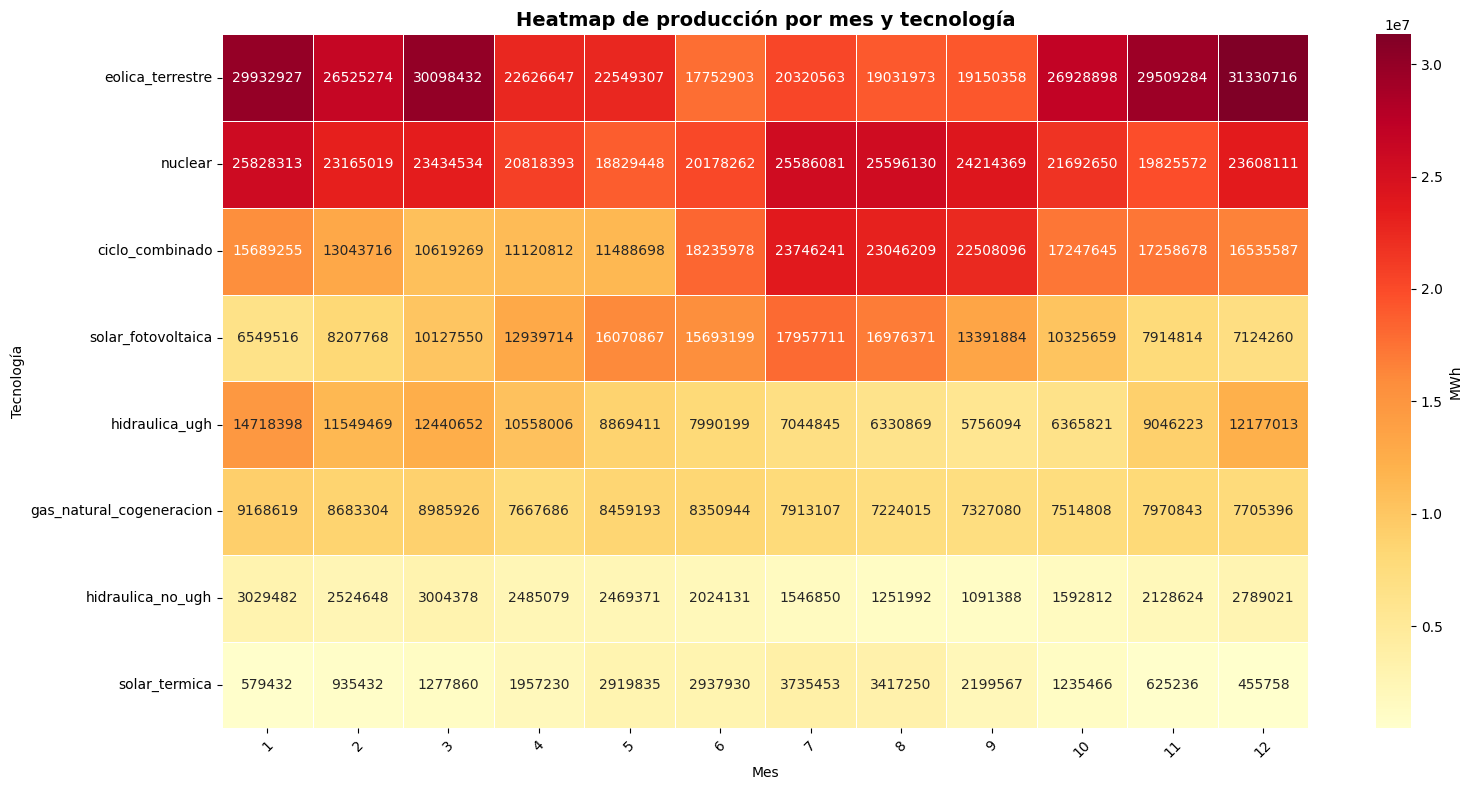

,media,std,cv,min,max,%_ceros,pearson_price,spearman_price
ciclo_combinado,4573.531,3228.378,0.706,18.600,17579.379,0.000,0.543,0.628
hulla_antracita,418.063,222.148,0.531,-31.019,1554.130,0.000,0.506,0.534
fuel,-0.000,0.001,1.833,-0.001,0.001,13.111,-0.425,-0.440
biomasa,395.253,81.005,0.205,91.432,568.492,0.000,0.423,0.384
residuos_domesticos_y_similares,158.149,38.581,0.244,34.797,219.892,0.000,0.363,0.387
hidraulica_no_ugh,591.538,242.294,0.410,111.140,1288.231,0.000,-0.349,-0.423
hulla_sub_bituminosa,133.306,183.358,1.375,-61.456,1245.426,0.000,0.307,0.194
derivados_del_petroleo_o_carbon,175.156,106.816,0.610,0.001,407.667,0.000,0.263,0.209
termica_no_renovable,422.313,1274.517,3.018,0.000,10371.400,37.657,-0.210,0.160
biogas,85.775,11.168,0.130,44.491,154.815,0.000,0.202,0.161


,media,std,cv,min,max,%_ceros,pearson_price,spearman_price
ciclo_combinado,4573.531,3228.378,0.706,18.600,17579.379,0.000,0.543,0.628
hulla_antracita,418.063,222.148,0.531,-31.019,1554.130,0.000,0.506,0.534
fuel,-0.000,0.001,1.833,-0.001,0.001,13.111,-0.425,-0.440
biomasa,395.253,81.005,0.205,91.432,568.492,0.000,0.423,0.384
residuos_domesticos_y_similares,158.149,38.581,0.244,34.797,219.892,0.000,0.363,0.387
hidraulica_no_ugh,591.538,242.294,0.410,111.140,1288.231,0.000,-0.349,-0.423
hulla_sub_bituminosa,133.306,183.358,1.375,-61.456,1245.426,0.000,0.307,0.194
derivados_del_petroleo_o_carbon,175.156,106.816,0.610,0.001,407.667,0.000,0.263,0.209
termica_no_renovable,422.313,1274.517,3.018,0.000,10371.400,37.657,-0.210,0.160
biogas,85.775,11.168,0.130,44.491,154.815,0.000,0.202,0.161


,media,std,cv,min,max,%_ceros,pearson_price,spearman_price


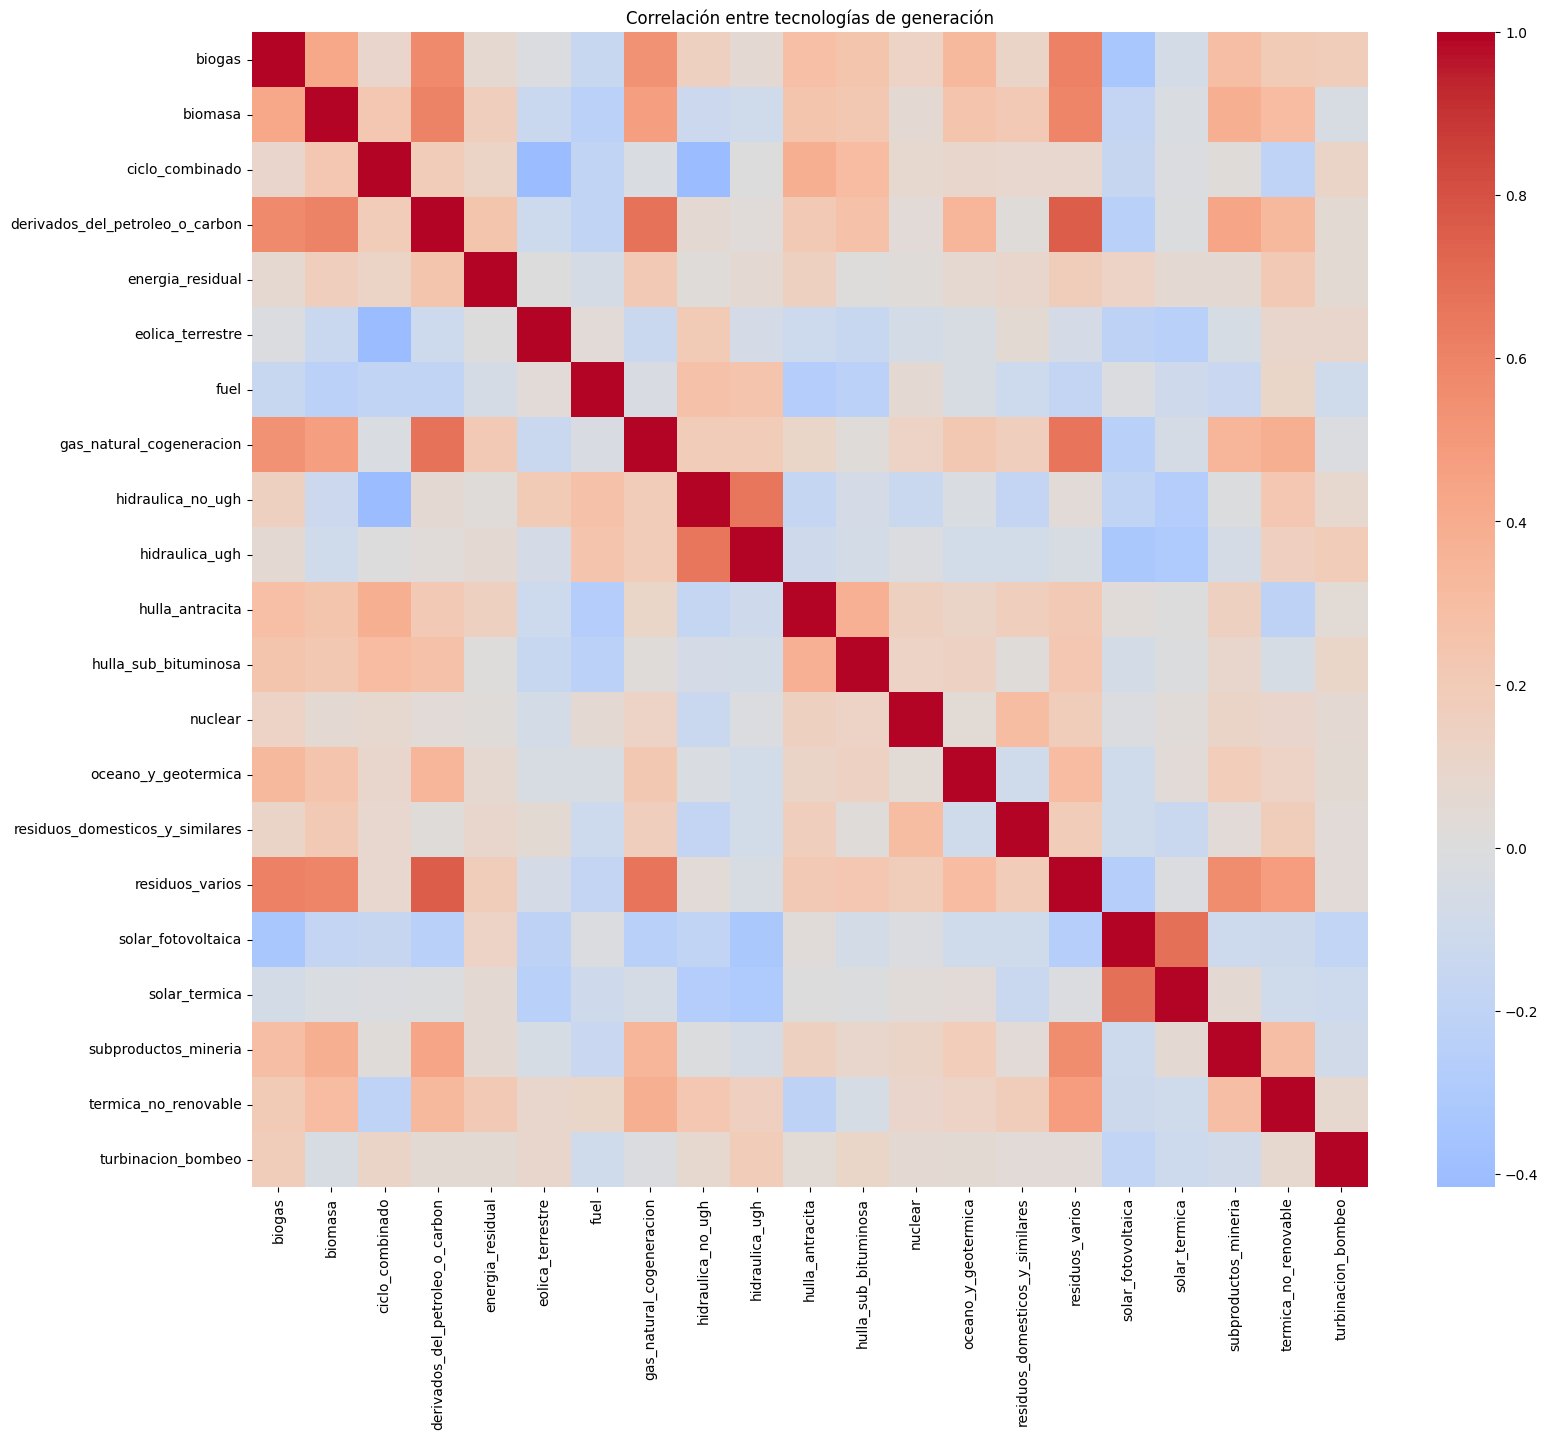


Pares de tecnologías con correlación ≥ 0.60:
                    tecnologia_1                    tecnologia_2  correlacion
                         biogas                 residuos_varios     0.614147
                        biomasa derivados_del_petroleo_o_carbon     0.602768
derivados_del_petroleo_o_carbon        gas_natural_cogeneracion     0.676707
derivados_del_petroleo_o_carbon                 residuos_varios     0.760544
       gas_natural_cogeneracion                 residuos_varios     0.666920
              hidraulica_no_ugh                  hidraulica_ugh     0.658267
             solar_fotovoltaica                   solar_termica     0.679311
Correlacion:

>= 0.60 -> posible agrupacion

>= 0.80 -> fuerte redundancia

>= 0.90 -> redundancia muy alta


VIF (Variance Inflation Factor) para detectar multicolinealidad:
                        variable       VIF
                         biogas 94.615097
                        nuclear 44.920469
                        biomasa 42.

In [10]:
# =========================
# 1 Agrupar tecnologias
# =========================

#Hay dos criterios posibles: por tipo de tecnologia o por correlacion entre ellas.


# Producción total y porcentaje por tipo de energía y mes
generacion_cols = [
    "biogas", "biomasa", "ciclo_combinado",
    "derivados_del_petroleo_o_carbon", "energia_residual",
    "eolica_terrestre", "fuel", "gas_natural_cogeneracion",
    "hidraulica_no_ugh", "hidraulica_ugh", "hulla_antracita",
    "hulla_sub_bituminosa", "nuclear", "oceano_y_geotermica",
    "residuos_domesticos_y_similares", "residuos_varios",
    "solar_fotovoltaica", "solar_termica", "subproductos_mineria",
    "termica_no_renovable", "turbinacion_bombeo"
]

# Añadir columna de año
df['year'] = pd.to_datetime(df['datetime']).dt.year  # Ajusta según tu columna de fecha
mensual_anual = df.groupby(['year', 'month'])[generacion_cols].sum()

# Crear una figura con subplots por año
años = mensual_anual.index.get_level_values('year').unique()
fig, axes = plt.subplots(len(años), 1, figsize=(14, 4*len(años)))

for i, año in enumerate(años):
    datos_año = mensual_anual.xs(año, level=0)
    # Calcular porcentaje
    datos_año_pct = datos_año.div(datos_año.sum(axis=1), axis=0) * 100
    
    # Graficar solo top 10 tecnologías
    top_tecnologias = datos_año.mean().sort_values(ascending=False).head(10).index
    datos_año_pct[top_tecnologias].plot(kind='line', marker='o', ax=axes[i])
    axes[i].set_title(f'Evolución mensual - {año}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Porcentaje (%)')
    axes[i].set_xlabel('Mes')
    axes[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

mensual = df.groupby("month")[generacion_cols].sum()
# Crear heatmap por mes y tecnología principal
tecnologias_top = mensual.mean().sort_values(ascending=False).head(8).index
datos_heatmap = mensual[tecnologias_top].T  # Transponer

plt.figure(figsize=(16, 8))
sns.heatmap(datos_heatmap, cmap='YlOrRd', annot=True, fmt='.0f', 
            cbar_kws={'label': 'MWh'}, linewidths=0.5)
plt.title('Heatmap de producción por mes y tecnología', fontsize=14, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Tecnología')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

'''
#Juntar por tipo de tecnologia:

Posible lista:
nuclear
eolica
hidraulica
solar
otras_renovables
ciclo_combinado
otras_termicas
turbinacion_bombeo

#Juntar tipos de energias:

df["renovables"] = (
    df["eolica_terrestre"]
    + df["hidraulica_no_ugh"]
    + df["hidraulica_ugh"]
    + df["solar_fotovoltaica"]
    + df["solar_termica"]
    + df["biogas"]
    + df["biomasa"]
    + df["oceano_y_geotermica"]
)

df["solar"] = (
    df["solar_fotovoltaica"]
    + df["solar_termica"]
)

df["hidraulica"] = (
    df["hidraulica_no_ugh"]
    + df["hidraulica_ugh"]
)

df["termica"] = (
    df["ciclo_combinado"]
    + df["hulla_antracita"]
    + df["hulla_sub_bituminosa"]
    + df["derivados_del_petroleo_o_carbon"]
    + df["fuel"]
)
'''

# =========================
# 2 Tabala resumen de estadisticas de las variables de generacion
# =========================


analisis = pd.DataFrame(index=generacion_cols)

analisis["media"] = df[generacion_cols].mean()
analisis["std"] = df[generacion_cols].std()

analisis["cv"] = (
    analisis["std"] / analisis["media"].abs()
)

analisis["min"] = df[generacion_cols].min()
analisis["max"] = df[generacion_cols].max()

analisis["%_ceros"] = (
    (df[generacion_cols] == 0).mean() * 100
)

analisis["pearson_price"] = [
    df[col].corr(df["price"], method="pearson")
    for col in generacion_cols
]

analisis["spearman_price"] = [
    df[col].corr(df["price"], method="spearman")
    for col in generacion_cols
]

analisis = analisis.sort_values(
    "pearson_price",
    key=abs,
    ascending=False
)

display(analisis.round(3))




# =========================
# 3 Analisis de correlacion entre variables de generacion
# =========================

analisis = pd.DataFrame(index=generacion_cols)

analisis["media"] = df[generacion_cols].mean()
analisis["std"] = df[generacion_cols].std()

analisis["cv"] = (
    analisis["std"] / analisis["media"].abs()
)

analisis["min"] = df[generacion_cols].min()
analisis["max"] = df[generacion_cols].max()

analisis["%_ceros"] = (
    (df[generacion_cols] == 0).mean() * 100
)

analisis["pearson_price"] = [
    df[col].corr(df["price"], method="pearson")
    for col in generacion_cols
]

analisis["spearman_price"] = [
    df[col].corr(df["price"], method="spearman")
    for col in generacion_cols
]

analisis = analisis.sort_values(
    "pearson_price",
    key=abs,
    ascending=False
)

display(analisis.round(3))


# =========================
# 4 Detectar enegias redundantes (poco utiles para predecir el precio)
# =========================

candidatas_baja_variabilidad = analisis[
    (analisis["cv"] < 0.05) |
    (analisis["%_ceros"] > 80)
]

display(candidatas_baja_variabilidad)



# =========================
# 5 Detectar enegias redundantes (poco utiles para predecir el precio)
# =========================

#Heatmap de correlacion entre variables de generacion
corr_generacion = df[generacion_cols].corr()

plt.figure(figsize=(18, 15))

sns.heatmap(
    corr_generacion,
    cmap="coolwarm",
    center=0
)

plt.title("Correlación entre tecnologías de generación")
plt.show()


# pares de variables con correlacion alta (>= 0.60)
# Si la tienen, pueden agruparse o incluso eliminarse algunas de ellas para evitar
# multicolinealidad en modelos de ML
pares = []

for i in range(len(generacion_cols)):
    for j in range(i + 1, len(generacion_cols)):

        corr = corr_generacion.iloc[i, j]

        if abs(corr) >= 0.60:
            pares.append({
                "tecnologia_1": generacion_cols[i],
                "tecnologia_2": generacion_cols[j],
                "correlacion": corr
            })

pares = pd.DataFrame(pares)

pares.sort_values(
    "correlacion",
    key=abs,
    ascending=False
)

print("\nPares de tecnologías con correlación ≥ 0.60:\n", pares.to_string(index=False))
print("Correlacion:\n")
print(">= 0.60 -> posible agrupacion\n")
print(">= 0.80 -> fuerte redundancia\n")
print(">= 0.90 -> redundancia muy alta\n")


#Pero la correlacion de dos variables de una en una no detecta toda la multicolinealidad,
# para eso podemos comprobar tambien la Variance Inflation Factor (VIF)
# Esto  da una justificacion estadistica mucho mas solida para reducir variables(Memoria)

from statsmodels.stats.outliers_influence import variance_inflation_factor

generacion_cols = df[generacion_cols].copy()

vif = pd.DataFrame()
vif["variable"] = generacion_cols.columns
vif["VIF"] = [
    variance_inflation_factor(generacion_cols.values, i)
    for i in range(generacion_cols.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

print("\nVIF (Variance Inflation Factor) para detectar multicolinealidad:\n", vif.to_string(index=False))

print("VIF:\n")
print("< 5 -> aceptable\n")
print("5 - 10 -> moderada \n")
print(">= 10 -> fuerte\n")

,n_grupos,silhouette
0,2,0.109107
1,3,0.152957
2,4,0.199026
3,5,0.202749
4,6,0.205952
5,7,0.208123
6,8,0.197486
7,9,0.189529
8,10,0.247056


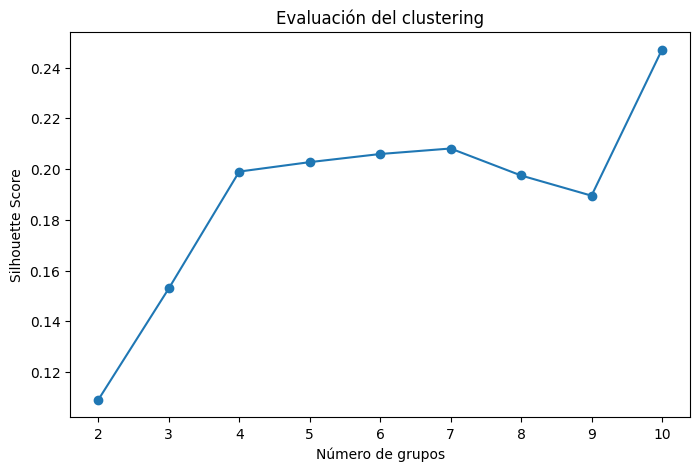

,tecnologia,grupo
12,nuclear,0
14,residuos_domesticos_y_similares,0
10,hulla_antracita,1
11,hulla_sub_bituminosa,1
0,biogas,2
1,biomasa,2
3,derivados_del_petroleo_o_carbon,2
7,gas_natural_cogeneracion,2
15,residuos_varios,2
19,termica_no_renovable,2



GRUPO 0
  - nuclear
  - residuos_domesticos_y_similares

GRUPO 1
  - hulla_antracita
  - hulla_sub_bituminosa

GRUPO 2
  - biogas
  - biomasa
  - derivados_del_petroleo_o_carbon
  - gas_natural_cogeneracion
  - residuos_varios
  - subproductos_mineria
  - termica_no_renovable

GRUPO 3
  - hidraulica_no_ugh
  - hidraulica_ugh

GRUPO 4
  - solar_fotovoltaica
  - solar_termica

GRUPO 5
  - energia_residual

GRUPO 6
  - ciclo_combinado
  - eolica_terrestre

GRUPO 7
  - fuel

GRUPO 8
  - oceano_y_geotermica

GRUPO 9
  - turbinacion_bombeo


,grupo,n_tecnologias,tecnologias,corr_media,corr_minima
0,0,2,"nuclear, residuos_domesticos_y_similares",0.298,0.298
1,1,2,"hulla_antracita, hulla_sub_bituminosa",0.380,0.380
2,2,7,"biogas, biomasa, derivados_del_petroleo_o_carb...",0.473,0.198
3,3,2,"hidraulica_no_ugh, hidraulica_ugh",0.658,0.658
4,4,2,"solar_fotovoltaica, solar_termica",0.679,0.679
5,5,1,energia_residual,NaN,NaN
6,6,2,"ciclo_combinado, eolica_terrestre",0.415,0.415
7,7,1,fuel,NaN,NaN
8,8,1,oceano_y_geotermica,NaN,NaN
9,9,1,turbinacion_bombeo,NaN,NaN


,pearson,spearman
grupo_2,-0.078,0.023
grupo_6,0.292,0.273
grupo_5,0.151,0.192
grupo_7,-0.425,-0.440
grupo_3,-0.135,-0.147
grupo_1,0.500,0.500
grupo_0,0.084,0.068
grupo_8,0.027,-0.044
grupo_4,-0.153,-0.096
grupo_9,0.133,0.125


,variable,VIF
0,biogas,94.615097
12,nuclear,44.920469
1,biomasa,42.979476
7,gas_natural_cogeneracion,35.288155
15,residuos_varios,28.943047
14,residuos_domesticos_y_similares,24.777103
8,hidraulica_no_ugh,20.676332
3,derivados_del_petroleo_o_carbon,13.110049
9,hidraulica_ugh,8.781020
10,hulla_antracita,7.423919


,variable,VIF
0,grupo_0,20.504557
6,grupo_6,9.402317
2,grupo_2,5.920752
1,grupo_1,4.498070
3,grupo_3,4.296098
8,grupo_8,2.400887
4,grupo_4,1.969000
9,grupo_9,1.742864
5,grupo_5,1.731738
7,grupo_7,1.546889


In [14]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from statsmodels.stats.outliers_influence import variance_inflation_factor


generacion_cols = [
    "biogas", "biomasa", "ciclo_combinado",
    "derivados_del_petroleo_o_carbon", "energia_residual",
    "eolica_terrestre", "fuel", "gas_natural_cogeneracion",
    "hidraulica_no_ugh", "hidraulica_ugh",
    "hulla_antracita", "hulla_sub_bituminosa",
    "nuclear", "oceano_y_geotermica",
    "residuos_domesticos_y_similares", "residuos_varios",
    "solar_fotovoltaica", "solar_termica",
    "subproductos_mineria", "termica_no_renovable",
    "turbinacion_bombeo"
]

corr = df[generacion_cols].corr()

distancia = 1 - corr.abs()
distancia = distancia.to_numpy(copy=True)
np.fill_diagonal(distancia, 0)



resultados_clustering = []

for n in range(2, 11):

    modelo = AgglomerativeClustering(
        n_clusters=n,
        metric="precomputed",
        linkage="average"
    )

    etiquetas = modelo.fit_predict(distancia)

    silhouette = silhouette_score(
        distancia,
        etiquetas,
        metric="precomputed"
    )

    resultados_clustering.append({
        "n_grupos": n,
        "silhouette": silhouette
    })

resultados_clustering = pd.DataFrame(resultados_clustering)

display(resultados_clustering)

plt.figure(figsize=(8, 5))

plt.plot(
    resultados_clustering["n_grupos"],
    resultados_clustering["silhouette"],
    marker="o"
)

plt.xlabel("Número de grupos")
plt.ylabel("Silhouette Score")
plt.title("Evaluación del clustering")

plt.show()


n_optimo = resultados_clustering.loc[
    resultados_clustering["silhouette"].idxmax(),
    "n_grupos"
]

modelo = AgglomerativeClustering(
    n_clusters=int(n_optimo),
    metric="precomputed",
    linkage="average"
)

etiquetas = modelo.fit_predict(distancia)

grupos = pd.DataFrame({
    "tecnologia": generacion_cols,
    "grupo": etiquetas
})

display(
    grupos.sort_values("grupo")
)

# mostrar las tecnologias agrupadas por grupo
for grupo, datos in grupos.groupby("grupo"):

    print(f"\nGRUPO {grupo}")
    
    for tecnologia in datos["tecnologia"]:
        print("  -", tecnologia)



# Analizar la correlación interna de cada grupo
analisis_grupos = []

for grupo, datos in grupos.groupby("grupo"):

    tecnologias = datos["tecnologia"].tolist()

    if len(tecnologias) > 1:

        subcorr = corr.loc[tecnologias, tecnologias]

        valores = subcorr.where(
            ~np.eye(len(tecnologias), dtype=bool)
        ).stack().abs()

        correlacion_media = valores.mean()
        correlacion_minima = valores.min()

    else:
        correlacion_media = np.nan
        correlacion_minima = np.nan

    analisis_grupos.append({
        "grupo": grupo,
        "n_tecnologias": len(tecnologias),
        "tecnologias": ", ".join(tecnologias),
        "corr_media": correlacion_media,
        "corr_minima": correlacion_minima
    })

analisis_grupos = pd.DataFrame(analisis_grupos)

display(
    analisis_grupos.round(3)
)


# Relación del grupo con price


for grupo, datos in grupos.groupby("grupo"):

    tecnologias = datos["tecnologia"].tolist()

    nombre = f"grupo_{grupo}"

    df[nombre] = df[tecnologias].sum(axis=1)


corr_grupos_price = {}

for grupo in grupos["grupo"].unique():

    nombre = f"grupo_{grupo}"

    corr_grupos_price[nombre] = {
        "pearson": df[nombre].corr(df["price"]),
        "spearman": df[nombre].corr(
            df["price"],
            method="spearman"
        )
    }

corr_grupos_price = pd.DataFrame(
    corr_grupos_price
).T

display(
    corr_grupos_price.round(3)
)


# VIF antes y despuésÇ

def calcular_vif(data, columnas):

    X = data[columnas].copy()

    resultado = pd.DataFrame({
        "variable": columnas,
        "VIF": [
            variance_inflation_factor(
                X.values,
                i
            )
            for i in range(len(columnas))
        ]
    })

    return resultado.sort_values(
        "VIF",
        ascending=False
    )


vif_original = calcular_vif(
    df,
    generacion_cols
)

display(vif_original)


columnas_grupos = [
    f"grupo_{g}"
    for g in sorted(grupos["grupo"].unique())
]

vif_agrupado = calcular_vif(
    df,
    columnas_grupos
)

display(vif_agrupado)